# Image Quality Basics

This notebook is the first learning checkpoint for `vision-imaging-lab`.

## Goals
- understand how grayscale images are represented
- measure brightness and contrast
- interpret histograms
- understand brightness shift and contrast scaling
- distinguish blur from noise
- compare denoising methods

This notebook is part of Stage 1: Learning Tutorial.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("Project root:", project_root)
print("Source path:", src_path)

Project root: E:\Workspace\vision-imaging-lab
Source path: E:\Workspace\vision-imaging-lab\src


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from image_utils import get_default_image_path, load_color_image, to_grayscale
from image_metrics import (
    measure_brightness,
    measure_contrast,
    measure_min_intensity,
    measure_max_intensity,
    measure_sharpness_laplacian,
    estimate_noise_std,
    measure_psnr,
)
from image_histograms import compute_grayscale_histogram
from image_transforms import (
    shift_brightness,
    scale_contrast,
    scale_contrast_around_mean,
    histogram_equalization,
    apply_clahe,
    gaussian_denoise,
    median_denoise,
    bilateral_denoise,
)

## 1. Load the image and convert to grayscale

A grayscale image is a 2D intensity array.
This is the main representation used in the first part of the project.

Color shape: (415, 768, 3)
Gray shape: (415, 768)
Dtype: uint8


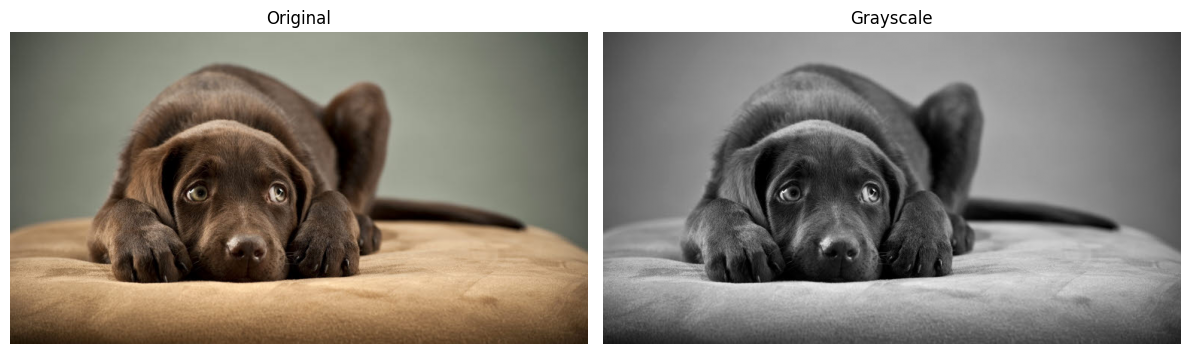

In [3]:
image_path = get_default_image_path()
image_bgr = load_color_image(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray_image = to_grayscale(image_bgr)

print("Color shape:", image_bgr.shape)
print("Gray shape:", gray_image.shape)
print("Dtype:", gray_image.dtype)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gray_image, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 2. Brightness and contrast

Brightness is approximated by mean grayscale intensity.
Contrast is approximated by the standard deviation of grayscale intensity.

In [4]:
print("Brightness:", measure_brightness(gray_image))
print("Contrast:", measure_contrast(gray_image))
print("Min intensity:", measure_min_intensity(gray_image))
print("Max intensity:", measure_max_intensity(gray_image))

Brightness: 116.13057542670683
Contrast: 47.19178295951851
Min intensity: 0
Max intensity: 252


## 3. Histogram

The histogram shows how many pixels fall into each intensity value from 0 to 255.
This is a discrete distribution, so a bar plot is more appropriate than a line plot.

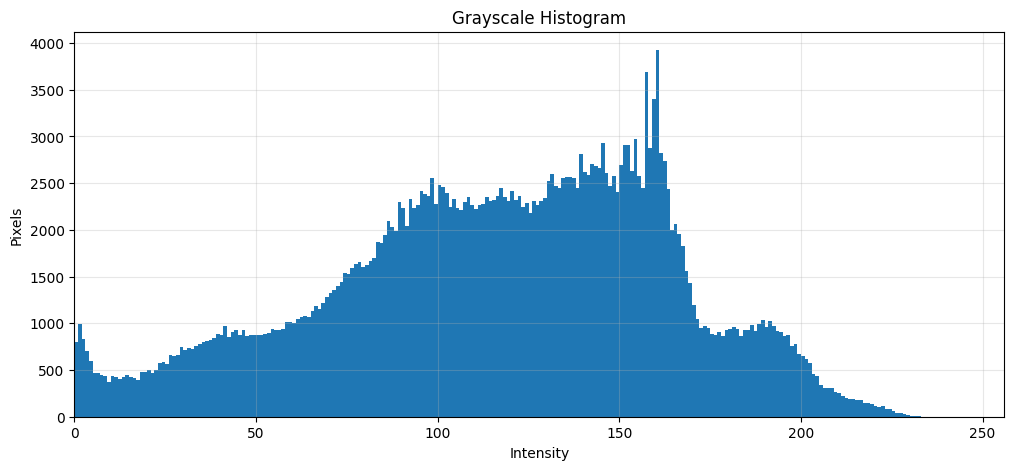

In [5]:
histogram, bins = compute_grayscale_histogram(gray_image)

plt.figure(figsize=(12, 5))
plt.bar(bins[:-1], histogram, width=1.0, align="edge")
plt.title("Grayscale Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixels")
plt.xlim(0, 256)
plt.grid(True, alpha=0.3)
plt.show()

## 4. Brightness shift

Brightness shift moves the histogram left or right.
Clipping happens when values go below 0 or above 255.

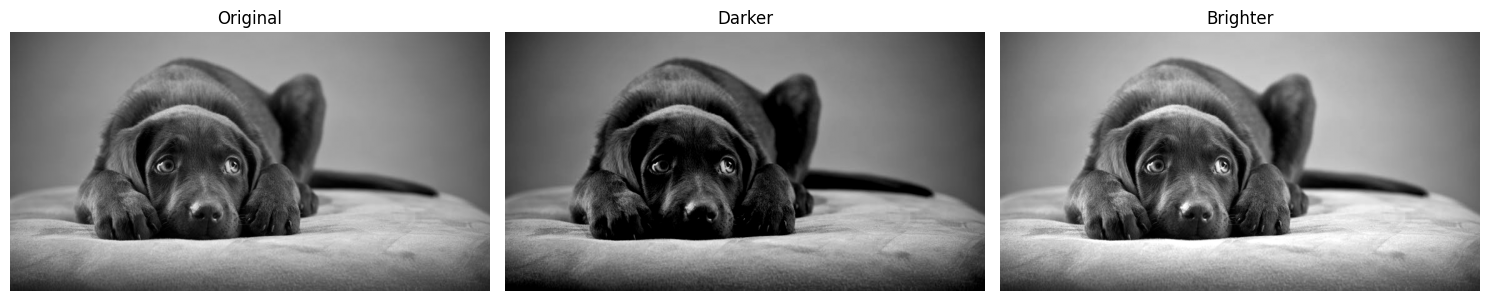

In [6]:
shift_value = 40
darker = shift_brightness(gray_image, -shift_value)
brighter = shift_brightness(gray_image, shift_value)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(darker, cmap="gray")
axes[1].set_title("Darker")
axes[1].axis("off")

axes[2].imshow(brighter, cmap="gray")
axes[2].set_title("Brighter")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 5. Contrast scaling

Naive contrast scaling changes intensity spread relative to 0.
Centered contrast scaling changes intensity spread relative to the image mean.
Centered contrast usually preserves overall brightness better.

Original brightness: 116.13057542670683
Naive brightness: 150.5952873995984
Centered brightness: 116.4894390060241
Original contrast: 47.19178295951851
Naive contrast: 60.66636755021006
Centered contrast: 59.47713279035389


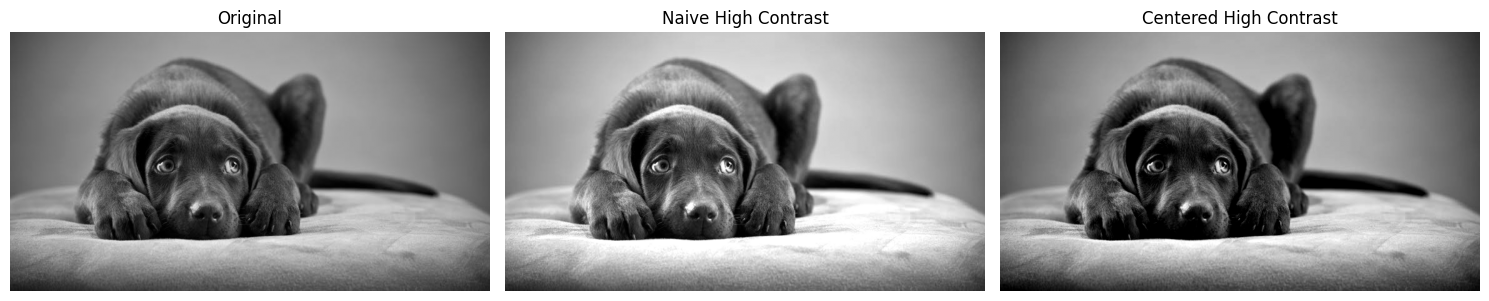

In [7]:
naive_high = scale_contrast(gray_image, 1.3)
centered_high = scale_contrast_around_mean(gray_image, 1.3)

print("Original brightness:", measure_brightness(gray_image))
print("Naive brightness:", measure_brightness(naive_high))
print("Centered brightness:", measure_brightness(centered_high))

print("Original contrast:", measure_contrast(gray_image))
print("Naive contrast:", measure_contrast(naive_high))
print("Centered contrast:", measure_contrast(centered_high))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(naive_high, cmap="gray")
axes[1].set_title("Naive High Contrast")
axes[1].axis("off")

axes[2].imshow(centered_high, cmap="gray")
axes[2].set_title("Centered High Contrast")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 6. Histogram equalization and CLAHE

Global histogram equalization can be too aggressive.
CLAHE is usually more controlled because it works locally and limits contrast amplification.

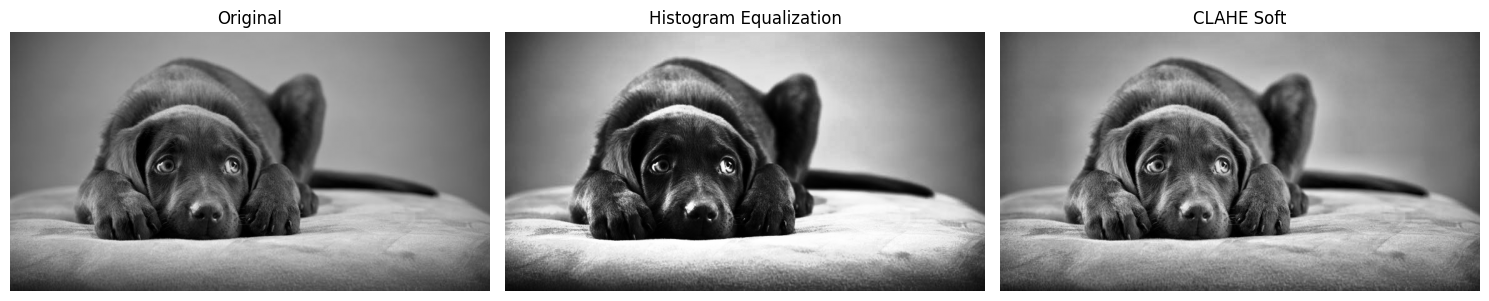

In [8]:
equalized = histogram_equalization(gray_image)
clahe_soft = apply_clahe(gray_image, clip_limit=1.0, tile_grid_size=(12, 12))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(equalized, cmap="gray")
axes[1].set_title("Histogram Equalization")
axes[1].axis("off")

axes[2].imshow(clahe_soft, cmap="gray")
axes[2].set_title("CLAHE Soft")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 7. Blur and sharpness

Blur removes edge structure.
Laplacian variance is a useful practical sharpness proxy.

In [9]:
blur_light = cv2.GaussianBlur(gray_image, (5, 5), 0)
blur_medium = cv2.GaussianBlur(gray_image, (11, 11), 0)
blur_strong = cv2.GaussianBlur(gray_image, (21, 21), 0)

print("Original sharpness:", measure_sharpness_laplacian(gray_image))
print("Light blur sharpness:", measure_sharpness_laplacian(blur_light))
print("Medium blur sharpness:", measure_sharpness_laplacian(blur_medium))
print("Strong blur sharpness:", measure_sharpness_laplacian(blur_strong))

Original sharpness: 202.79516886847045
Light blur sharpness: 12.726658117305048
Medium blur sharpness: 3.591722171969441
Strong blur sharpness: 1.9773245950256693


## 8. Noise and denoising

Noise adds random variation.
Blur removes real structure.
Denoising is always a tradeoff between noise reduction and detail preservation.

In [10]:
np.random.seed(42)
noise = np.random.normal(0, 15, gray_image.shape)
noisy_image = np.clip(gray_image.astype("float32") + noise, 0, 255).astype("uint8")

gaussian_image = gaussian_denoise(noisy_image, kernel_size=(5, 5), sigma=0)
median_image = median_denoise(noisy_image, kernel_size=5)
bilateral_image = bilateral_denoise(noisy_image, d=9, sigma_color=50, sigma_space=50)

for name, image in [
    ("Noisy", noisy_image),
    ("Gaussian", gaussian_image),
    ("Median", median_image),
    ("Bilateral", bilateral_image),
]:
    print(f"{name} estimated noise:", estimate_noise_std(image))
    print(f"{name} sharpness:", measure_sharpness_laplacian(image))
    print(f"{name} PSNR vs original:", measure_psnr(gray_image, image))
    print()

Noisy estimated noise: 13.782834
Noisy sharpness: 4610.011543353344
Noisy PSNR vs original: 24.672607

Gaussian estimated noise: 2.1805093
Gaussian sharpness: 31.113892365237806
Gaussian PSNR vs original: 32.99217

Median estimated noise: 2.5785227
Median sharpness: 80.67122174440736
Median PSNR vs original: 32.335476

Bilateral estimated noise: 2.8099093
Bilateral sharpness: 126.22920659812591
Bilateral PSNR vs original: 33.2821



## Conclusions

### What I learned
- brightness and contrast are different image properties
- histograms explain intensity distribution better than single summary numbers
- clipping causes information loss at 0 and 255
- quantization can create empty histogram bins after transforms
- centered contrast is more meaningful than naive contrast scaling
- histogram equalization can overdo enhancement
- CLAHE can improve local detail more gently
- blur removes edge information
- noise adds false high-frequency variation
- denoising is a tradeoff, not magic

### Best observations so far
- centered contrast is better than naive contrast on this image
- soft CLAHE gives the most balanced enhancement
- bilateral denoising gives the best overall compromise in the current denoising test